In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import drive
import os
import sys

# 2. Define your paths
base_path = "/content/drive/MyDrive/Environemnt"
depth_dir = os.path.join(base_path, "depthAnything")
mask_dir = os.path.join(base_path, "mask2former_model")

# 3. Install required libraries (Must be done every session)
!pip install -q transformers timm accelerate scikit-learn

import torch
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

# --- 1. INITIALIZE PATHS & SYSTEM ---
# Add the Depth-Anything repo to the system path so imports work
sys.path.append(os.path.join(depth_dir, 'Depth-Anything-V2'))
from depth_anything_v2.dpt import DepthAnythingV2


device = "cuda" if torch.cuda.is_available() else "cpu"

# --- 2. LOAD DEPTH ANYTHING V2 ---
print("Loading Depth-Anything-V2 from Drive...")
depth_weights = os.path.join(depth_dir, 'depth_anything_v2_vits.pth')
depth_model = DepthAnythingV2(encoder='vits', features=64, out_channels=[48, 96, 192, 384])
depth_model.load_state_dict(torch.load(depth_weights, map_location=device, weights_only=False))
depth_model.to(device).eval()

# --- 3. LOAD MASK2FORMER (Permanent Storage) ---
print("Loading Mask2Former...")
model_name = "facebook/mask2former-swin-tiny-ade-semantic"

m2f_processor = AutoImageProcessor.from_pretrained(model_name, cache_dir=mask_dir)

# FIX: Add .to(device) here
m2f_model = Mask2FormerForUniversalSegmentation.from_pretrained(
    model_name,
    cache_dir=mask_dir
).to(device).eval()

Mounted at /content/drive


Loading Depth-Anything-V2 from Drive...
Loading Mask2Former...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `Mask2FormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

1. Upload ROOM Image:


Saving Stair1.jpeg to Stair1.jpeg

2. Upload TILE Image:


Saving cda1560f-c1a2-4c95-b20c-3615cbbdc027.png to cda1560f-c1a2-4c95-b20c-3615cbbdc027.png

Processing high-resolution visualization...


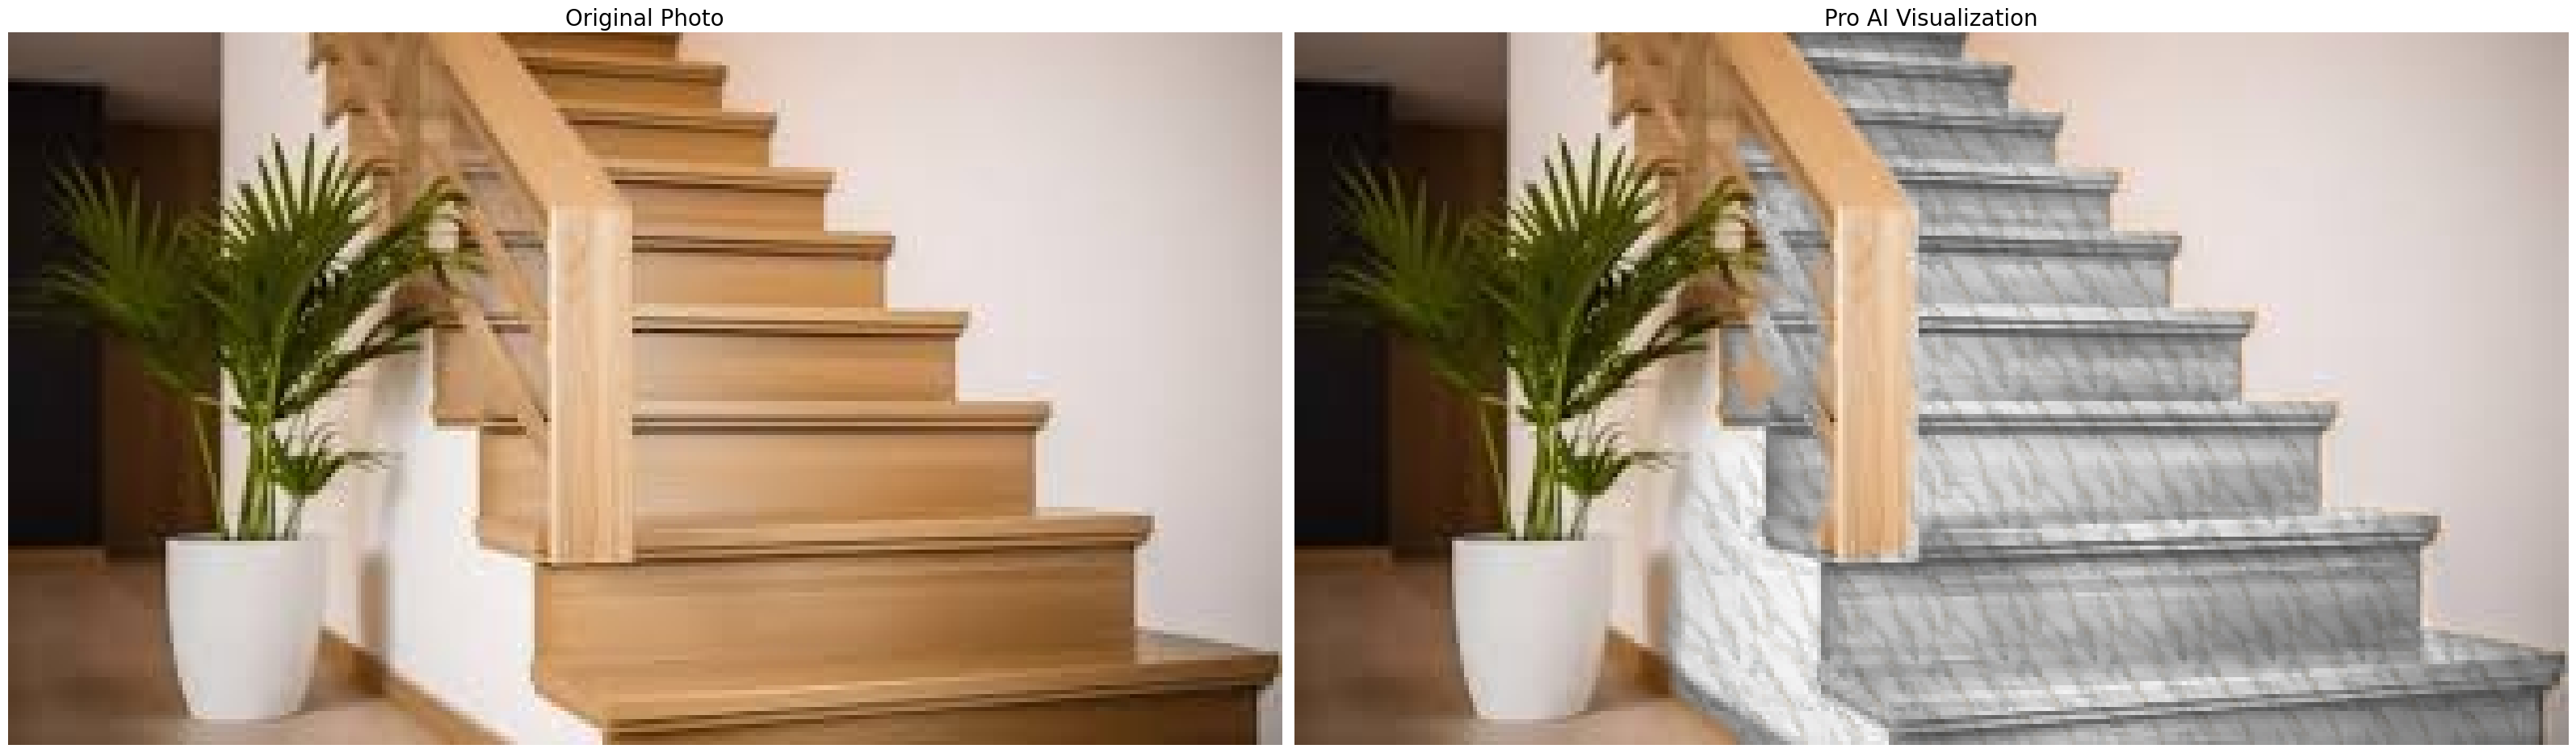

In [ ]:
# -*- coding: utf-8 -*-
"""
Professional Staircase Visualization - High-Res Side-by-Side Output
Features: Auto-Scaling, Pattern Sharpness, and Large Display Format
"""

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

# --- 1. CORE VISUALIZATION ENGINE ---
def apply_pro_auto_tiling(room_img, tile_img, stair_mask):
    h, w = room_img.shape[:2]

    # A. AUTOMATIC SCALE ESTIMATION (From your logic)
    y_coords, _ = np.where(stair_mask > 0)
    if len(y_coords) == 0: return room_img

    stair_height_pixels = np.max(y_coords) - np.min(y_coords)

    # Target ~10-12 repetitions for optimal pattern visibility
    target_tile_h = max(int(stair_height_pixels / 10), 32)
    aspect_ratio = tile_img.shape[1] / tile_img.shape[0]
    target_tile_w = int(target_tile_h * aspect_ratio)

    # B. ANTI-ALIASED SHARPENING (Fixes the "Big Pixel" issue)
    tile_ready = cv2.resize(tile_img, (target_tile_w, target_tile_h), interpolation=cv2.INTER_AREA)

    # Restore micro-details with Unsharp Masking
    gaussian = cv2.GaussianBlur(tile_ready, (0, 0), 1.5)
    tile_ready = cv2.addWeighted(tile_ready, 1.6, gaussian, -0.6, 0)

    # C. CREATE REPEATED PATTERN FIELD
    repeat_x = (w // target_tile_w) + 2
    repeat_y = (h // target_tile_h) + 2
    tiled_field = np.tile(tile_ready, (repeat_y, repeat_x, 1))[:h, :w]

    # D. LUMINOSITY-BASED 3D PRESERVATION
    lab = cv2.cvtColor(room_img, cv2.COLOR_BGR2Lab)
    l_channel, _, _ = cv2.split(lab)

    # Enhance shadows and 3D edges for "pop"
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l_map = clahe.apply(l_channel).astype(float) / 255.0

    # E. PATTERN-PRIORITY BLEND (Visibility Floor)
    tile_f = tiled_field.astype(float) / 255.0
    pattern_blend = tile_f * (l_map[:, :, np.newaxis] * 0.7 + 0.3)

    # F. FINAL SEAMLESS COMPOSITE
    alpha = cv2.GaussianBlur(stair_mask.astype(float), (7, 7), 0)[:, :, np.newaxis]
    room_f = room_img.astype(float) / 255.0
    final = (room_f * (1 - alpha)) + (pattern_blend * alpha)

    return (np.clip(final, 0, 1) * 255).astype(np.uint8)

# --- 2. RUNNER ---
try:
    from google.colab import files

    # Sequential uploads to avoid list index errors
    print("1. Upload ROOM Image:")
    uploaded_room = files.upload()
    room_name = list(uploaded_room.keys())[0]
    room_cv = cv2.imread(room_name)

    print("\n2. Upload TILE Image:")
    uploaded_tile = files.upload()
    tile_name = list(uploaded_tile.keys())[0]
    tile_cv = cv2.imread(tile_name)

    print("\nProcessing high-resolution visualization...")

    # Mask2Former Logic (Target Label 59 for Stairs)
    with torch.no_grad():
        inputs = m2f_processor(images=room_cv, return_tensors="pt").to(device)
        outputs = m2f_model(**inputs)
        seg = m2f_processor.post_process_semantic_segmentation(outputs, target_sizes=[room_cv.shape[:2]])[0].cpu().numpy()

    stair_mask = (seg == 59).astype(np.uint8)

    # Apply Visualizer
    final_output = apply_pro_auto_tiling(room_cv, tile_cv, stair_mask)

    # Display Side-by-Side in High Resolution
    # We increase 'figsize' and use 'subplots' for a single row
    plt.figure(figsize=(32, 16)) # Force large image size
    plt.subplot(1, 2, 1)
    plt.title("Original Photo", fontsize=20)
    plt.imshow(cv2.cvtColor(room_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Pro AI Visualization", fontsize=20)
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")

1. Upload ROOM Image:


Saving Stair1.jpeg to Stair1 (3).jpeg

2. Upload TILE Image:


Saving download (1).jpeg to download (1).jpeg

Processing high-resolution visualization...


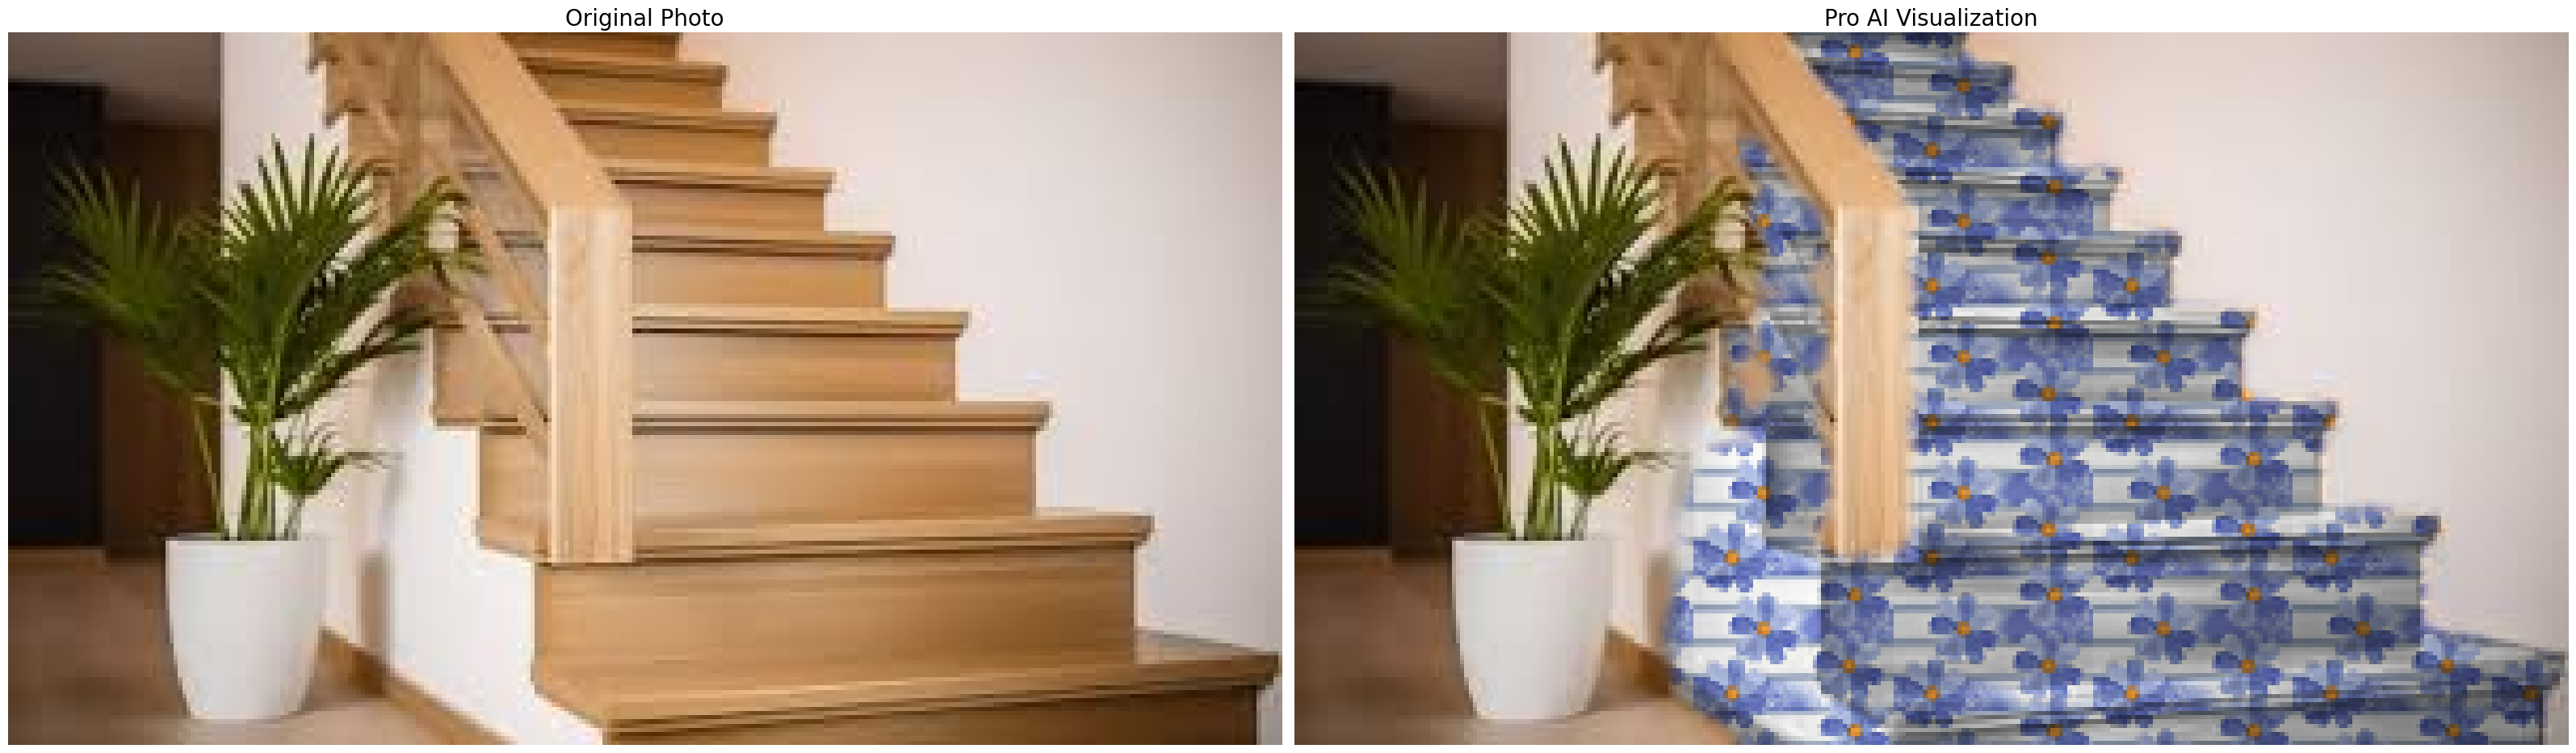

In [ ]:
# --- 2. RUNNER ---
try:
    from google.colab import files

    # Sequential uploads to avoid list index errors
    print("1. Upload ROOM Image:")
    uploaded_room = files.upload()
    room_name = list(uploaded_room.keys())[0]
    room_cv = cv2.imread(room_name)

    print("\n2. Upload TILE Image:")
    uploaded_tile = files.upload()
    tile_name = list(uploaded_tile.keys())[0]
    tile_cv = cv2.imread(tile_name)

    print("\nProcessing high-resolution visualization...")

    # Mask2Former Logic (Target Label 59 for Stairs)
    with torch.no_grad():
        inputs = m2f_processor(images=room_cv, return_tensors="pt").to(device)
        outputs = m2f_model(**inputs)
        seg = m2f_processor.post_process_semantic_segmentation(outputs, target_sizes=[room_cv.shape[:2]])[0].cpu().numpy()

    stair_mask = (seg == 59).astype(np.uint8)

    # Apply Visualizer
    final_output = apply_pro_auto_tiling(room_cv, tile_cv, stair_mask)

    # Display Side-by-Side in High Resolution
    # We increase 'figsize' and use 'subplots' for a single row
    plt.figure(figsize=(32, 16)) # Force large image size
    plt.subplot(1, 2, 1)
    plt.title("Original Photo", fontsize=20)
    plt.imshow(cv2.cvtColor(room_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Pro AI Visualization", fontsize=20)
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")

1. Upload ROOM Image:


Saving Stair1.jpeg to Stair1 (8).jpeg

2. Upload TILE Image:


Saving IMG_5300_88d86d09-4f25-4cc4-b85f-ef8e73c3a6dc.jpg to IMG_5300_88d86d09-4f25-4cc4-b85f-ef8e73c3a6dc.jpg

Processing high-resolution visualization...


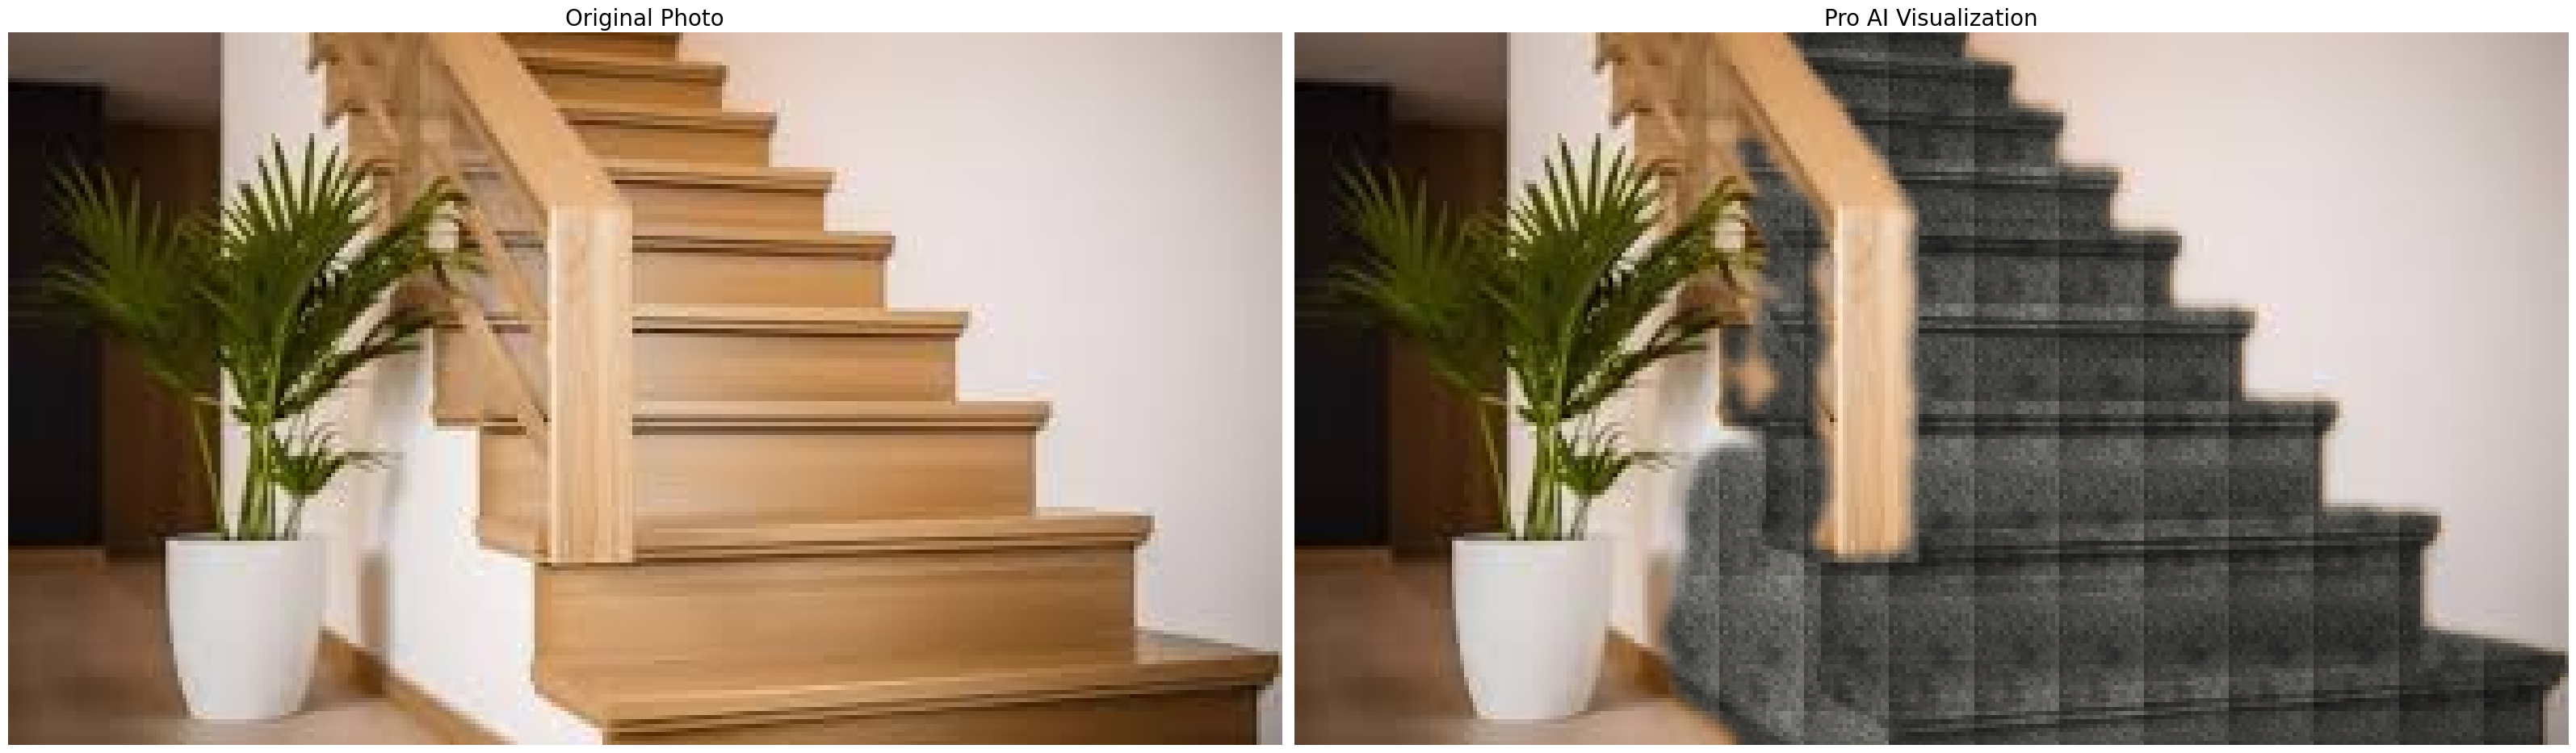

In [ ]:
# --- 2. RUNNER ---
try:
    from google.colab import files

    # Sequential uploads to avoid list index errors
    print("1. Upload ROOM Image:")
    uploaded_room = files.upload()
    room_name = list(uploaded_room.keys())[0]
    room_cv = cv2.imread(room_name)

    print("\n2. Upload TILE Image:")
    uploaded_tile = files.upload()
    tile_name = list(uploaded_tile.keys())[0]
    tile_cv = cv2.imread(tile_name)

    print("\nProcessing high-resolution visualization...")

    # Mask2Former Logic (Target Label 59 for Stairs)
    with torch.no_grad():
        inputs = m2f_processor(images=room_cv, return_tensors="pt").to(device)
        outputs = m2f_model(**inputs)
        seg = m2f_processor.post_process_semantic_segmentation(outputs, target_sizes=[room_cv.shape[:2]])[0].cpu().numpy()

    stair_mask = (seg == 59).astype(np.uint8)

    # Apply Visualizer
    final_output = apply_pro_auto_tiling(room_cv, tile_cv, stair_mask)

    # Display Side-by-Side in High Resolution
    # We increase 'figsize' and use 'subplots' for a single row
    plt.figure(figsize=(32, 16)) # Force large image size
    plt.subplot(1, 2, 1)
    plt.title("Original Photo", fontsize=20)
    plt.imshow(cv2.cvtColor(room_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Pro AI Visualization", fontsize=20)
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")

1. Upload ROOM Image:


Saving Stair1.jpeg to Stair1 (5).jpeg

2. Upload TILE Image:


Saving flat-lay-abstract-metal-wallpaper-close-up.jpg to flat-lay-abstract-metal-wallpaper-close-up.jpg

Processing high-resolution visualization...


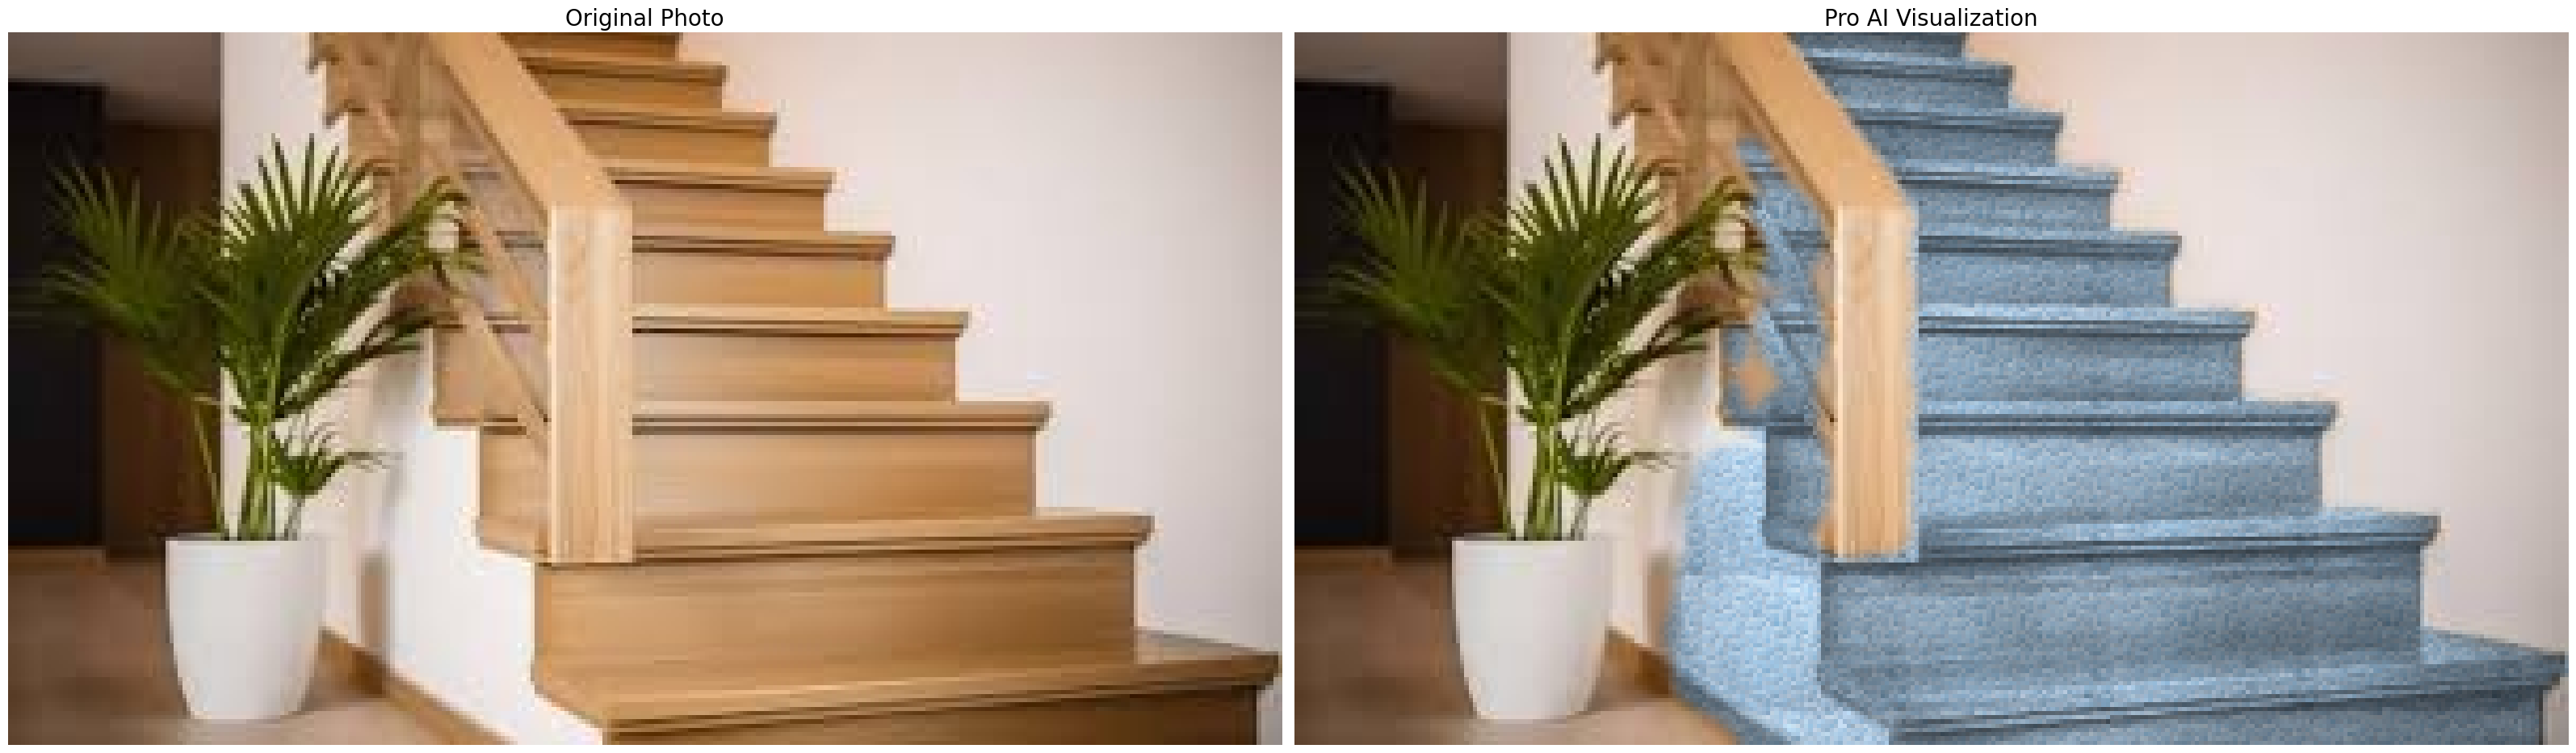

In [ ]:
# --- 2. RUNNER ---
try:
    from google.colab import files

    # Sequential uploads to avoid list index errors
    print("1. Upload ROOM Image:")
    uploaded_room = files.upload()
    room_name = list(uploaded_room.keys())[0]
    room_cv = cv2.imread(room_name)

    print("\n2. Upload TILE Image:")
    uploaded_tile = files.upload()
    tile_name = list(uploaded_tile.keys())[0]
    tile_cv = cv2.imread(tile_name)

    print("\nProcessing high-resolution visualization...")

    # Mask2Former Logic (Target Label 59 for Stairs)
    with torch.no_grad():
        inputs = m2f_processor(images=room_cv, return_tensors="pt").to(device)
        outputs = m2f_model(**inputs)
        seg = m2f_processor.post_process_semantic_segmentation(outputs, target_sizes=[room_cv.shape[:2]])[0].cpu().numpy()

    stair_mask = (seg == 59).astype(np.uint8)

    # Apply Visualizer
    final_output = apply_pro_auto_tiling(room_cv, tile_cv, stair_mask)

    # Display Side-by-Side in High Resolution
    # We increase 'figsize' and use 'subplots' for a single row
    plt.figure(figsize=(32, 16)) # Force large image size
    plt.subplot(1, 2, 1)
    plt.title("Original Photo", fontsize=20)
    plt.imshow(cv2.cvtColor(room_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Pro AI Visualization", fontsize=20)
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")


1. Upload ROOM Image:


Saving images (7).jpeg to images (7).jpeg

2. Upload TILE Image:


Saving Screenshot 2026-02-26 134116.png to Screenshot 2026-02-26 134116.png

Processing high-resolution visualization...


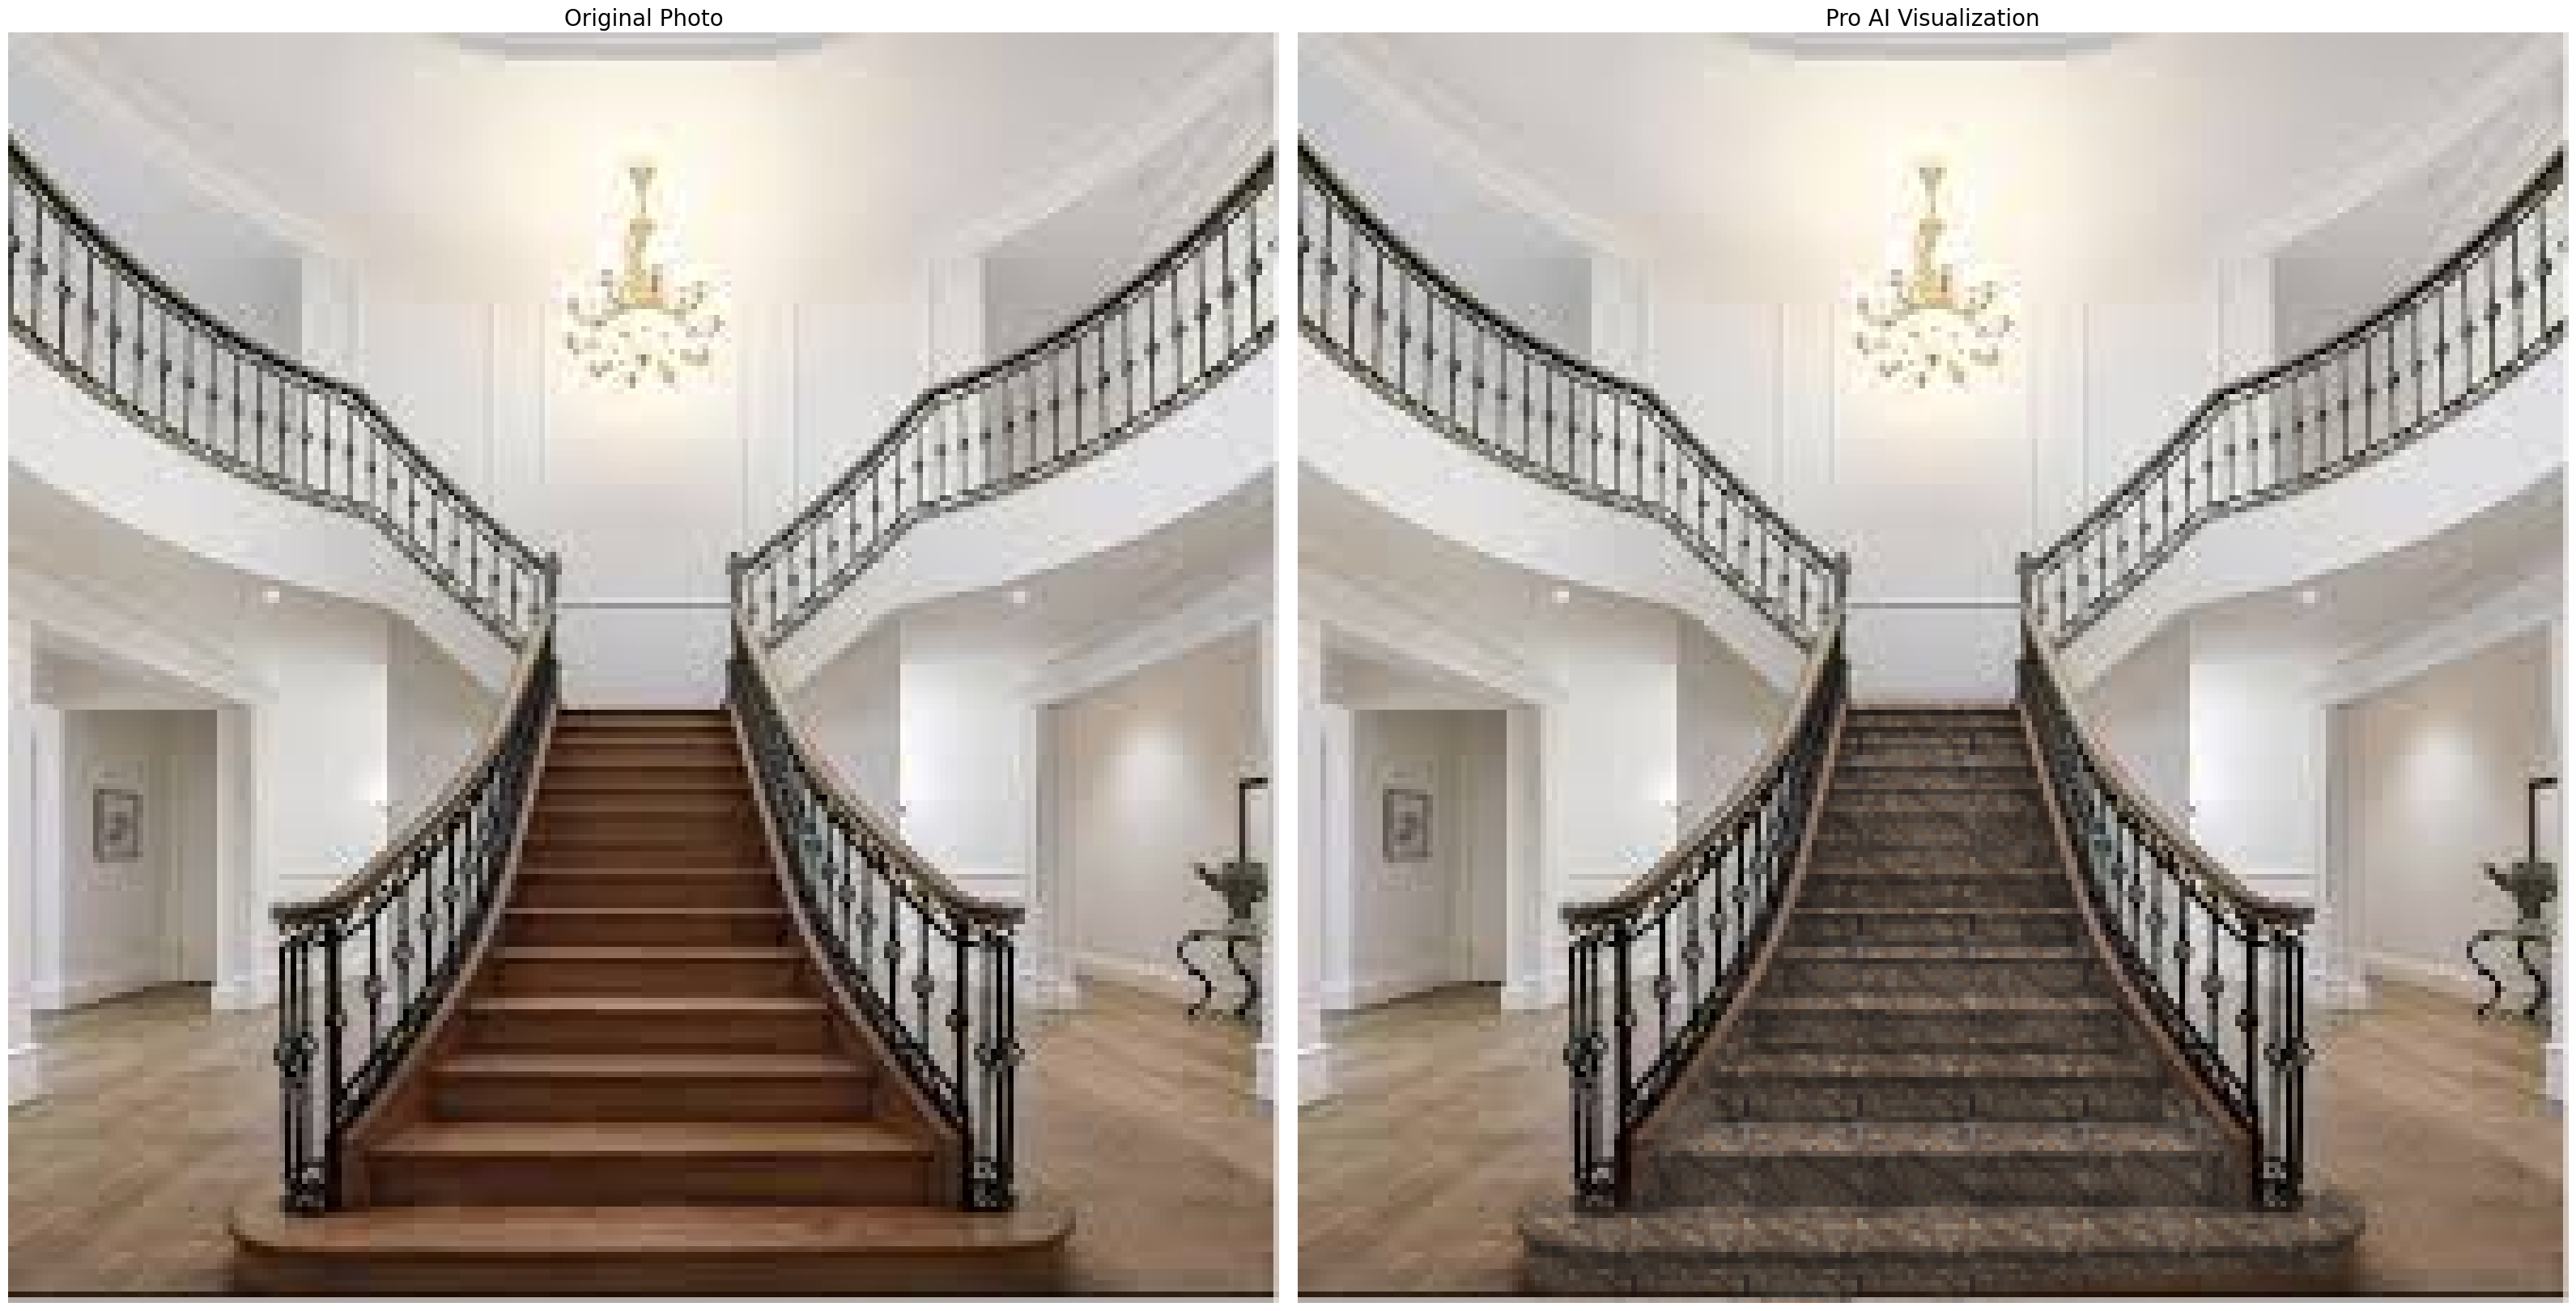

In [ ]:
# --- 2. RUNNER ---
try:
    from google.colab import files

    # Sequential uploads to avoid list index errors
    print("1. Upload ROOM Image:")
    uploaded_room = files.upload()
    room_name = list(uploaded_room.keys())[0]
    room_cv = cv2.imread(room_name)

    print("\n2. Upload TILE Image:")
    uploaded_tile = files.upload()
    tile_name = list(uploaded_tile.keys())[0]
    tile_cv = cv2.imread(tile_name)

    print("\nProcessing high-resolution visualization...")

    # Mask2Former Logic (Target Label 59 for Stairs)
    with torch.no_grad():
        inputs = m2f_processor(images=room_cv, return_tensors="pt").to(device)
        outputs = m2f_model(**inputs)
        seg = m2f_processor.post_process_semantic_segmentation(outputs, target_sizes=[room_cv.shape[:2]])[0].cpu().numpy()

    stair_mask = (seg == 59).astype(np.uint8)

    # Apply Visualizer
    final_output = apply_pro_auto_tiling(room_cv, tile_cv, stair_mask)

    # Display Side-by-Side in High Resolution
    # We increase 'figsize' and use 'subplots' for a single row
    plt.figure(figsize=(32, 16)) # Force large image size
    plt.subplot(1, 2, 1)
    plt.title("Original Photo", fontsize=20)
    plt.imshow(cv2.cvtColor(room_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Pro AI Visualization", fontsize=20)
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")

1. Upload ROOM Image:


Saving images (7).jpeg to images (7) (1).jpeg

2. Upload TILE Image:


Saving images (1).png to images (1).png

Processing high-resolution visualization...


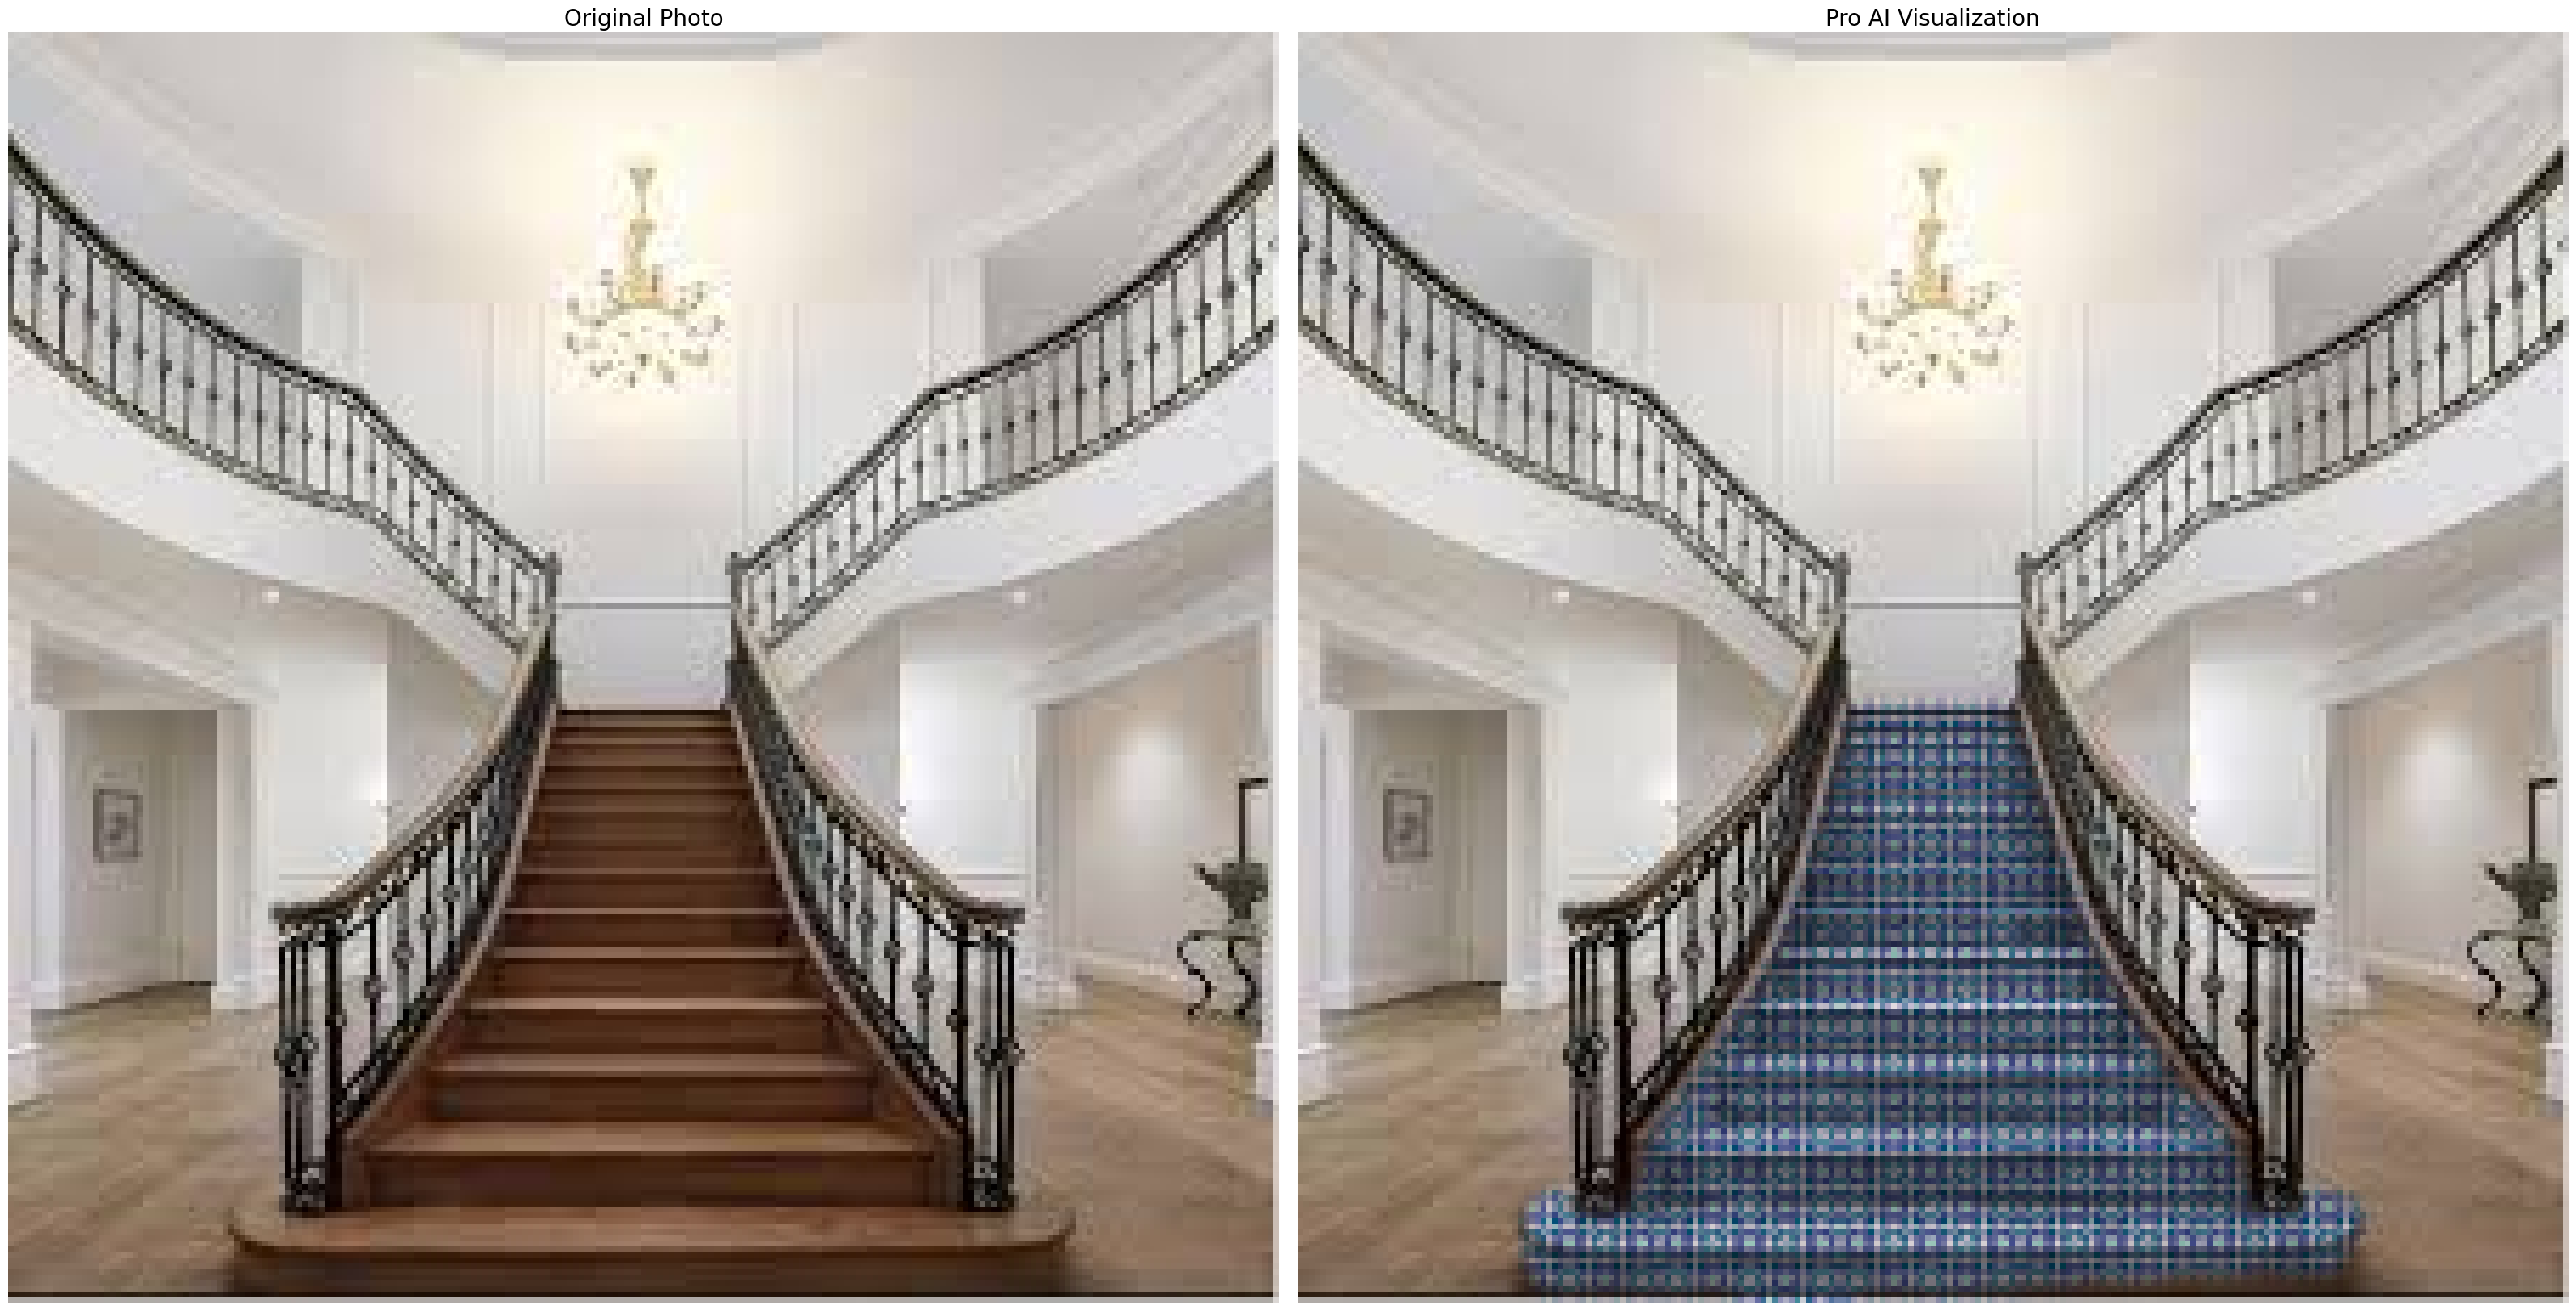

In [ ]:
# --- 2. RUNNER ---
try:
    from google.colab import files

    # Sequential uploads to avoid list index errors
    print("1. Upload ROOM Image:")
    uploaded_room = files.upload()
    room_name = list(uploaded_room.keys())[0]
    room_cv = cv2.imread(room_name)

    print("\n2. Upload TILE Image:")
    uploaded_tile = files.upload()
    tile_name = list(uploaded_tile.keys())[0]
    tile_cv = cv2.imread(tile_name)

    print("\nProcessing high-resolution visualization...")

    # Mask2Former Logic (Target Label 59 for Stairs)
    with torch.no_grad():
        inputs = m2f_processor(images=room_cv, return_tensors="pt").to(device)
        outputs = m2f_model(**inputs)
        seg = m2f_processor.post_process_semantic_segmentation(outputs, target_sizes=[room_cv.shape[:2]])[0].cpu().numpy()

    stair_mask = (seg == 59).astype(np.uint8)

    # Apply Visualizer
    final_output = apply_pro_auto_tiling(room_cv, tile_cv, stair_mask)

    # Display Side-by-Side in High Resolution
    # We increase 'figsize' and use 'subplots' for a single row
    plt.figure(figsize=(32, 16)) # Force large image size
    plt.subplot(1, 2, 1)
    plt.title("Original Photo", fontsize=20)
    plt.imshow(cv2.cvtColor(room_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Pro AI Visualization", fontsize=20)
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")

1. Upload ROOM Image:


Saving stairs3.jpeg to stairs3.jpeg

2. Upload TILE Image:


Saving IMG_5300_88d86d09-4f25-4cc4-b85f-ef8e73c3a6dc.jpg to IMG_5300_88d86d09-4f25-4cc4-b85f-ef8e73c3a6dc (1).jpg

Processing high-resolution visualization...


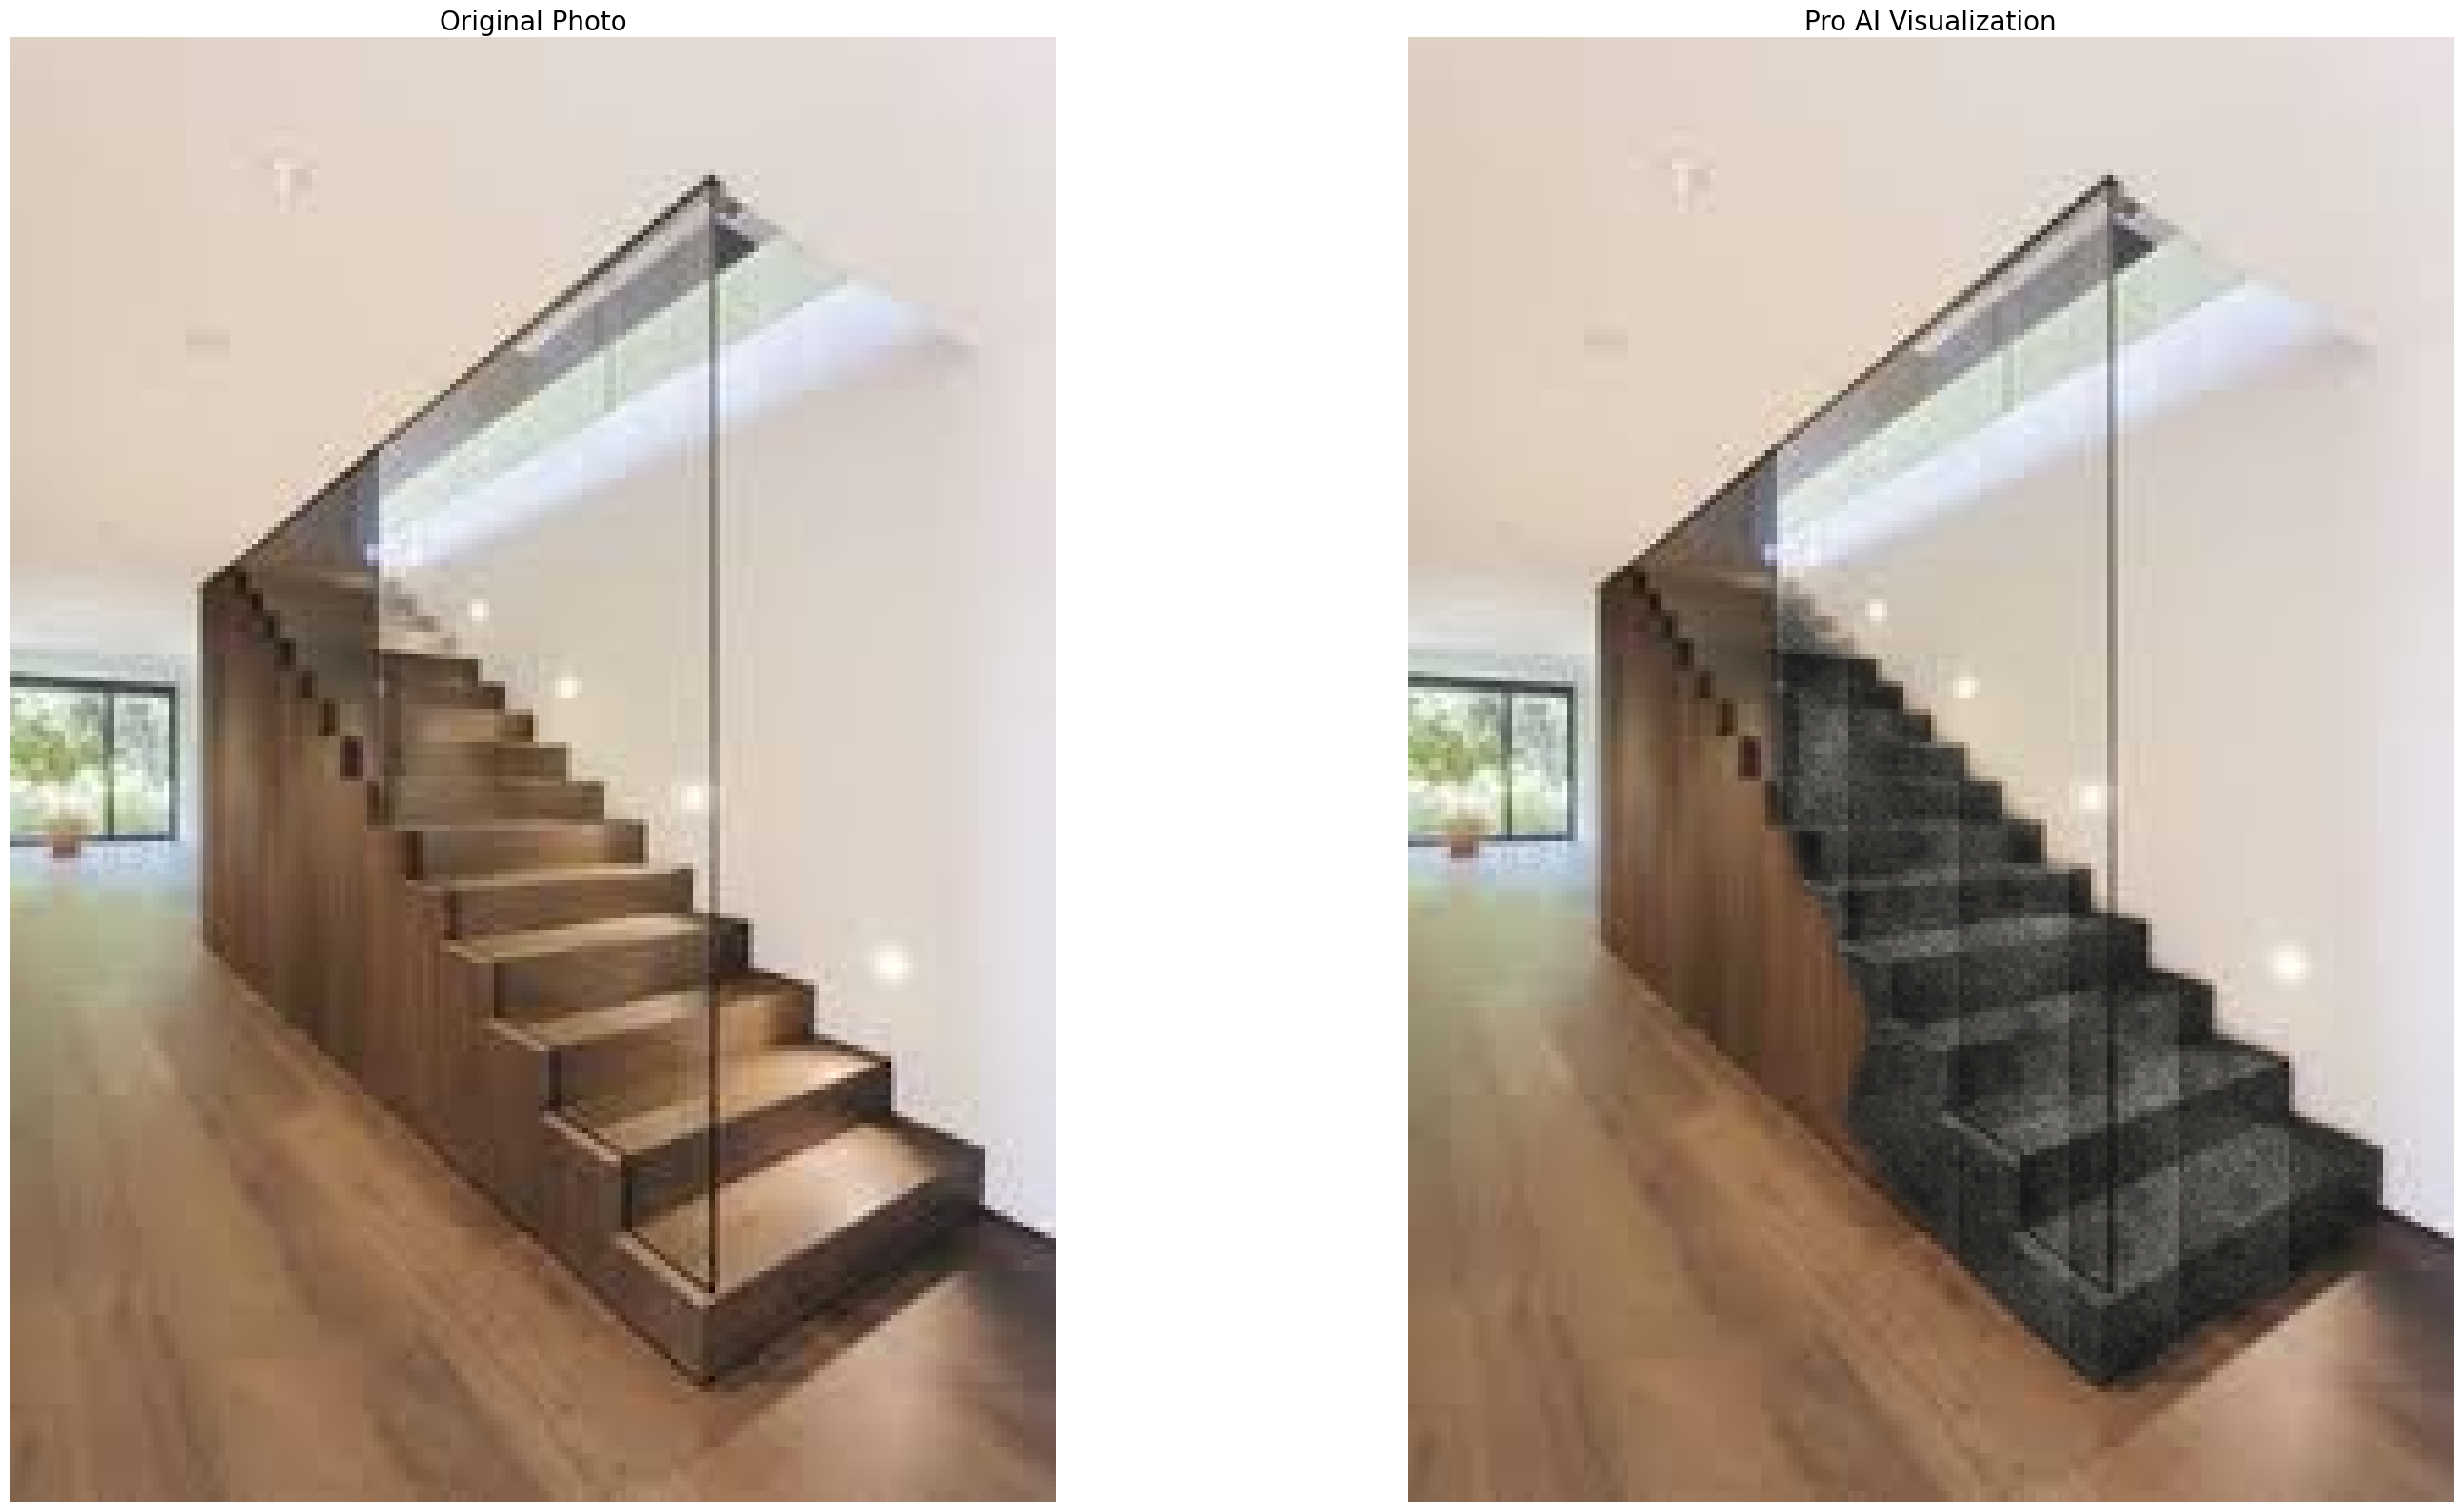

In [ ]:
# --- 2. RUNNER ---
try:
    from google.colab import files

    # Sequential uploads to avoid list index errors
    print("1. Upload ROOM Image:")
    uploaded_room = files.upload()
    room_name = list(uploaded_room.keys())[0]
    room_cv = cv2.imread(room_name)

    print("\n2. Upload TILE Image:")
    uploaded_tile = files.upload()
    tile_name = list(uploaded_tile.keys())[0]
    tile_cv = cv2.imread(tile_name)

    print("\nProcessing high-resolution visualization...")

    # Mask2Former Logic (Target Label 59 for Stairs)
    with torch.no_grad():
        inputs = m2f_processor(images=room_cv, return_tensors="pt").to(device)
        outputs = m2f_model(**inputs)
        seg = m2f_processor.post_process_semantic_segmentation(outputs, target_sizes=[room_cv.shape[:2]])[0].cpu().numpy()

    stair_mask = (seg == 59).astype(np.uint8)

    # Apply Visualizer
    final_output = apply_pro_auto_tiling(room_cv, tile_cv, stair_mask)

    # Display Side-by-Side in High Resolution
    # We increase 'figsize' and use 'subplots' for a single row
    plt.figure(figsize=(32, 16)) # Force large image size
    plt.subplot(1, 2, 1)
    plt.title("Original Photo", fontsize=20)
    plt.imshow(cv2.cvtColor(room_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Pro AI Visualization", fontsize=20)
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")

1. Upload ROOM Image:


Saving stairs4.jpeg to stairs4.jpeg

2. Upload TILE Image:


Saving tile5.jpg.webp to tile5.jpg (1).webp

Processing high-resolution visualization...


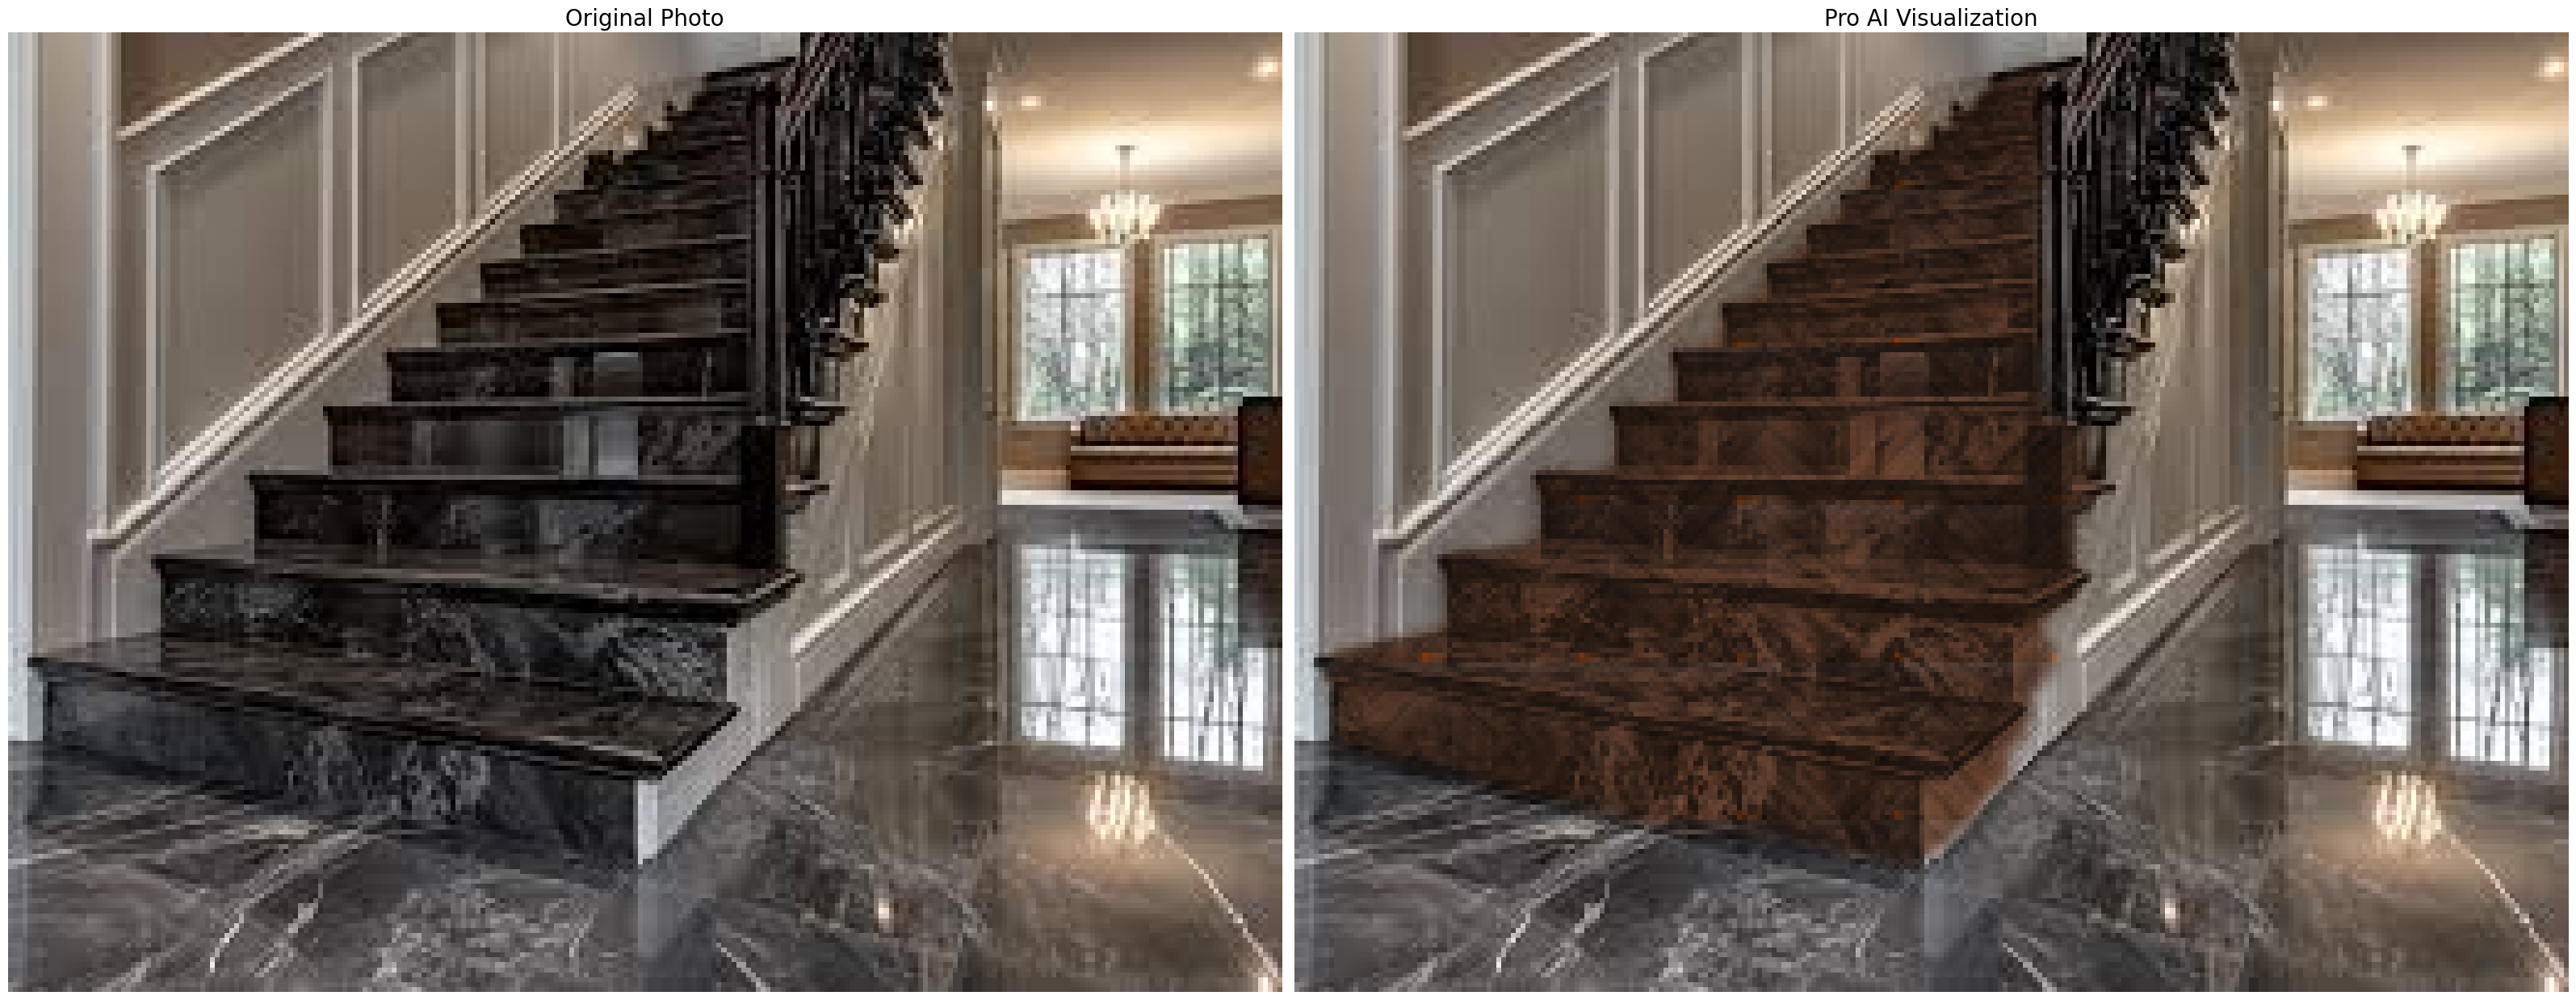

In [ ]:
# --- 2. RUNNER ---
try:
    from google.colab import files

    # Sequential uploads to avoid list index errors
    print("1. Upload ROOM Image:")
    uploaded_room = files.upload()
    room_name = list(uploaded_room.keys())[0]
    room_cv = cv2.imread(room_name)

    print("\n2. Upload TILE Image:")
    uploaded_tile = files.upload()
    tile_name = list(uploaded_tile.keys())[0]
    tile_cv = cv2.imread(tile_name)

    print("\nProcessing high-resolution visualization...")

    # Mask2Former Logic (Target Label 59 for Stairs)
    with torch.no_grad():
        inputs = m2f_processor(images=room_cv, return_tensors="pt").to(device)
        outputs = m2f_model(**inputs)
        seg = m2f_processor.post_process_semantic_segmentation(outputs, target_sizes=[room_cv.shape[:2]])[0].cpu().numpy()

    stair_mask = (seg == 59).astype(np.uint8)

    # Apply Visualizer
    final_output = apply_pro_auto_tiling(room_cv, tile_cv, stair_mask)

    # Display Side-by-Side in High Resolution
    # We increase 'figsize' and use 'subplots' for a single row
    plt.figure(figsize=(32, 16)) # Force large image size
    plt.subplot(1, 2, 1)
    plt.title("Original Photo", fontsize=20)
    plt.imshow(cv2.cvtColor(room_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Pro AI Visualization", fontsize=20)
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")